In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import joblib
import time

In [21]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset_V3.csv')
X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']

In [22]:
df

,address_line_2,h_id,n_cafe_5km,near_Royal_Palace_in_km,n_gas_station_5km,near_Phsar_Tmey_in_km,near_Vattanac_Tower_in_km,near_Phsar_kandal_in_km,near_Phsar_Chas_in_km,near_Wat_Phnom_in_km,near_Sisowath_Riverside_Park_in_km,near_Bassac_Lane_in_km,near_Olympic_Stadium_in_km,near_Boeng_Keng_Kang_1_in_km,n_secondary_school_5km,price_per_m2
0,78,450,168,5,174,4,4,5,5,4,5,4,3,4,73,3357.98
1,48,476,143,4,113,4,4,4,5,5,4,2,3,2,61,3809.30
2,45,351,138,5,148,3,3,5,4,3,5,5,3,5,61,3437.03
3,45,464,169,4,169,3,3,4,3,3,4,4,2,4,75,3469.70
4,14,427,98,3,49,4,4,3,3,4,3,3,5,3,34,5442.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9267,0,822,1,15,0,14,14,14,14,14,14,16,15,16,0,729.57
9268,66,378,11,11,16,11,10,11,10,10,11,13,12,13,3,571.98
9269,59,596,1,20,2,18,18,20,19,18,20,20,18,20,0,260.40
9270,26,653,6,16,14,15,15,16,16,15,16,15,14,15,3,1093.83


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [25]:
svr_pipe = make_pipeline(
    StandardScaler(),
    SVR()
)

In [26]:
param_grid = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__epsilon': [0.01, 0.1, 0.5, 1],
    'svr__kernel': ['linear', 'rbf', 'poly'],
    'svr__gamma': ['scale', 'auto'],
    'svr__degree': [2, 3]
}

In [27]:
grid_search = GridSearchCV(
    estimator=svr_pipe,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=3
)

In [28]:
print("Starting SVR hyperparameter tuning...")
start_time = time.time()

grid_search.fit(X_train_main, y_train_main)

print(f"Tuning completed in {time.time()-start_time:.2f} seconds")
print("Best parameters found:")
print(grid_search.best_params_)

Starting SVR hyperparameter tuning...
Fitting 3 folds for each of 192 candidates, totalling 576 fits
Tuning completed in 162.29 seconds
Best parameters found:
{'svr__C': 100, 'svr__degree': 2, 'svr__epsilon': 0.1, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}


In [29]:
best_svr = grid_search.best_estimator_

In [30]:
y_pred_train = best_svr.predict(X_train)
y_pred_test = best_svr.predict(X_test)

In [31]:
def print_metrics(y_true, y_pred, set_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100

    print(f"\n{set_name} Set Metrics (SVR):")
    print(f"R²: {r2:.4f}")
    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    if set_name == "Test":
        print(f"Avg Price: {y_true.mean():.2f}")
    return mae

In [32]:
train_mae = print_metrics(y_train, y_pred_train, "Train")
test_mae = print_metrics(y_test, y_pred_test, "Test")


Train Set Metrics (SVR):
R²: 0.8909
MAE: 430.32
MAPE: 31.40%

Test Set Metrics (SVR):
R²: 0.8909
MAE: 433.25
MAPE: 30.71%
Avg Price: 2074.79


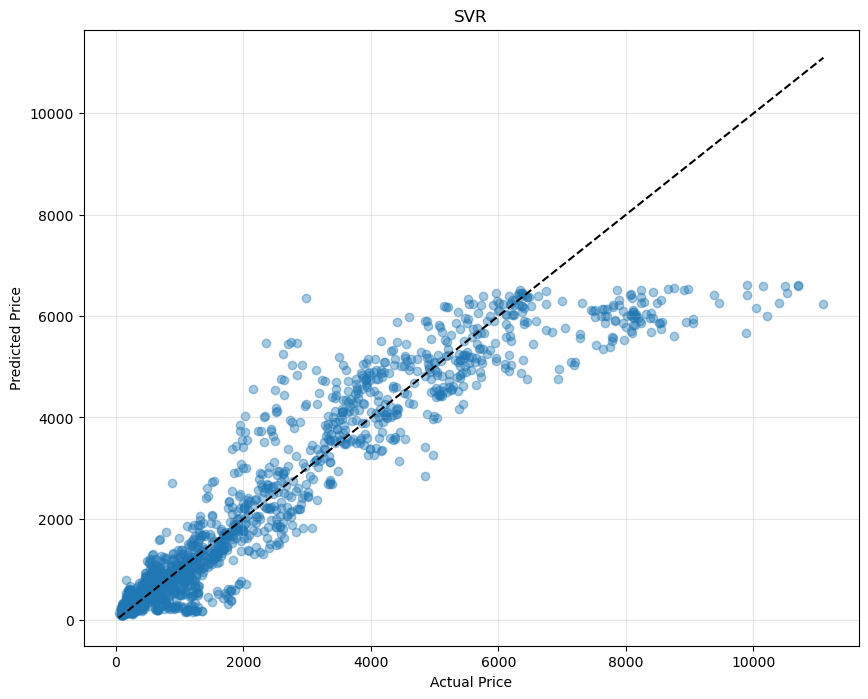

In [33]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("SVR")
plt.grid(alpha=0.3)
plt.savefig("svr_actual_vs_predicted.png", dpi=300)
plt.show()

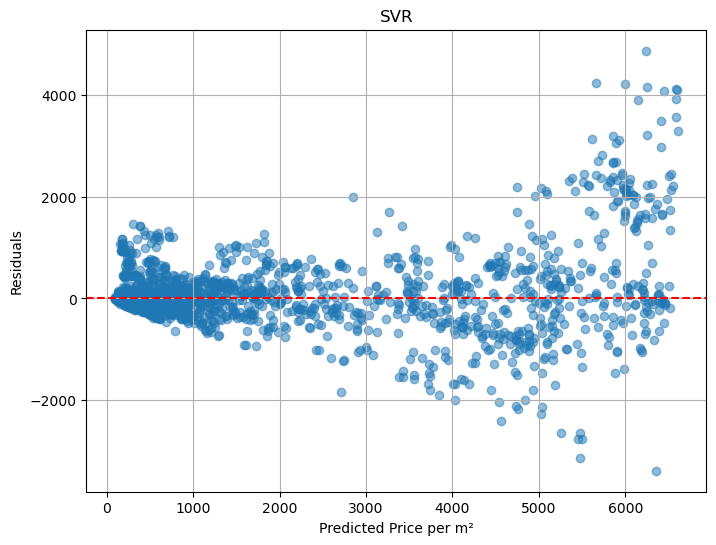

In [34]:
residuals = y_test - y_pred_test
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price per m²")
plt.ylabel("Residuals")
plt.title("SVR")
plt.grid(True)
plt.show()

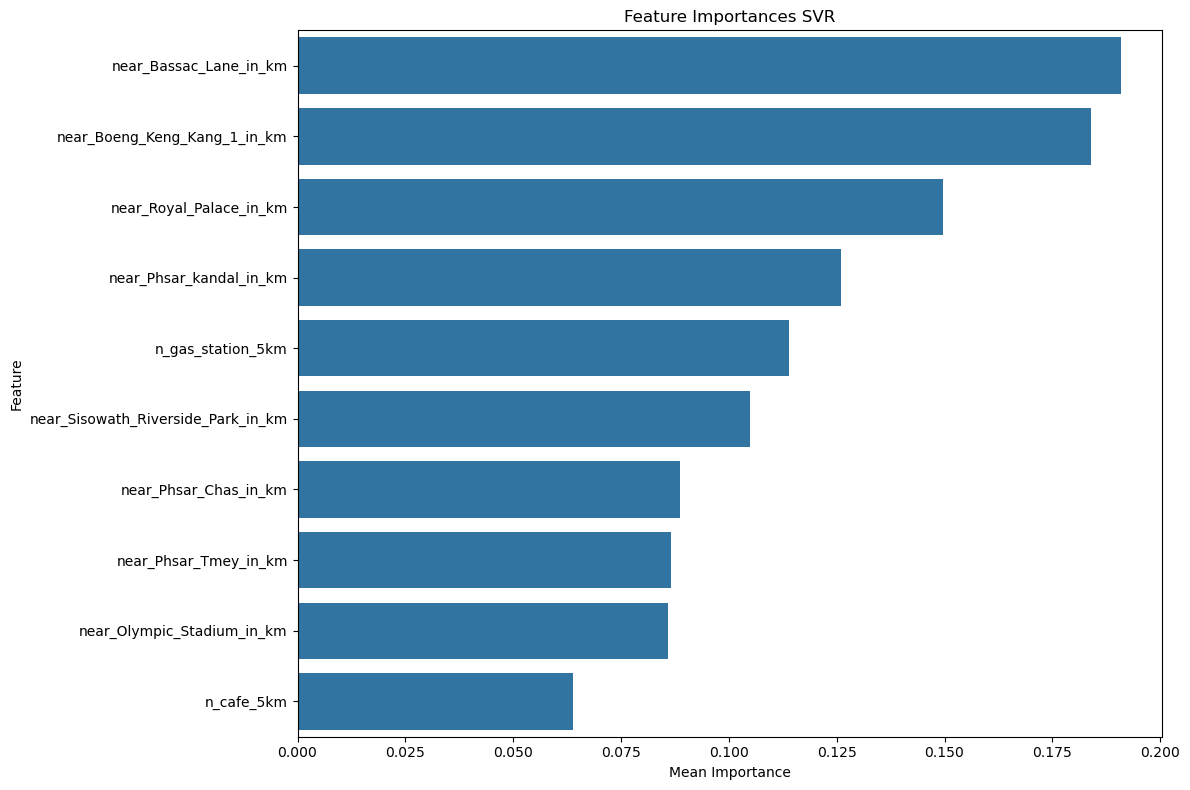

In [35]:
from sklearn.inspection import permutation_importance

result = permutation_importance(best_svr, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Sort importances
sorted_idx = np.argsort(result.importances_mean)[::-1]
sorted_features = X.columns[sorted_idx]

# Plot top 10 features
plt.figure(figsize=(12, 8))
sns.barplot(x=result.importances_mean[sorted_idx][:10], y=sorted_features[:10])
plt.title('Feature Importances SVR')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [36]:
def calculate_metrics(model, X_train, y_train, X_test, y_test, cv_folds=5):
    # Train set predictions
    y_pred_train = model.predict(X_train)
    
    # Test set predictions
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics for test set
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mape = np.mean(np.abs((y_test - y_pred_test) / np.maximum(y_test, 1))) * 100
    
    # Calculate train R2
    train_r2 = r2_score(y_train, y_pred_train)
    train_mae = mean_absolute_error(y_train, y_pred_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    train_mape = np.mean(np.abs((y_train - y_pred_train) / np.maximum(y_train, 1))) * 100

    
    
    # Create metrics dataframe
    metrics_df = pd.DataFrame({
        'Metric': ['R2(Test)', 'MAE', 'RMSE', 'MAPE', 'Train R2', 'MAE', 'RMSE', 'MAPE'],
        'Value': [test_r2, test_mae, test_rmse, test_mape, train_r2, train_mae, train_rmse, train_mape]
    })
    
    return metrics_df.round(4)

In [37]:
metrics_df = calculate_metrics(best_svr, X_train, y_train, X_test, y_test)
print("\nModel Performance Metrics:")
print("="*50)
print(metrics_df.to_string(index=False))
print("="*50)


Model Performance Metrics:
  Metric    Value
R2(Test)   0.8909
     MAE 433.2491
    RMSE 751.7322
    MAPE  30.7121
Train R2   0.8909
     MAE 430.3246
    RMSE 759.9112
    MAPE  31.4037


In [38]:
import joblib
joblib.dump(best_svr, "../../../models/svr/svr_model_label_v5.joblib")

['../../../models/svr/svr_model_label_v5.joblib']